### Simplify $Prob.(T \leq t)$ and plug into $f(t)$

We can actually simplify the calculation for $Prob.(T \leq t)$. To do so, let's re-examine equation given in part 5. The equation $\sum_{t=1}^n (1-d)^{t-1}d$ gives us the probability of surviving at least $t$ periods. The part $1-d$ is the chance of surviving, 1 - `death_chance`. Thus, $(1-d)^{t-1}$ gives us the chance of a protocell surviving to period $t-1$. We multiply this with $d$ to get the chance of not surviving past the current period $t$.

We can also find the chance of surviving at least $t$ periods by first finding the probability of surviving all $t$ periods using $(1-d)^t$ and then subracting this from 1.

$$Prob.(T \leq t) = \sum_{t=1}^n (1-d)^{t-1}d =  1-(1-d)^t$$

We'll modify `series_pleqt` from part 7 & 8 with this simpler calculation and show the result.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def series_pleqt(n_periods, death_chance):
    """Calculate P(T<=t) for n periods"""
    pleqt_series = pd.Series(
        [
            1-(1-death_chance)**t
            for t in range(0, n_periods+1)
        ],
        name="Prob(T<=t)",
        # index=(f"t={t:02}" for t in range(0, n_periods+1))
        )
    return pleqt_series

def pop_equilib(birth_rate, death_chance):
    """ Calculate the population equilibrium for population with constant birth rate
        and independent death chance"""

    return birth_rate/death_chance

In [23]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
n_periods = 25

In [24]:
cdf = series_pleqt(n_periods, death_chance)
cdf

0     0.000000
1     0.100000
2     0.190000
3     0.271000
4     0.343900
5     0.409510
6     0.468559
7     0.521703
8     0.569533
9     0.612580
10    0.651322
11    0.686189
12    0.717570
13    0.745813
14    0.771232
15    0.794109
16    0.814698
17    0.833228
18    0.849905
19    0.864915
20    0.878423
21    0.890581
22    0.901523
23    0.911371
24    0.920234
25    0.928210
Name: Prob(T<=t), dtype: float64

You can compare this result to the result given by running `series_pleqt` in part 7 to see that they are identical. You can also compare the code for the corresponding `series_pleqt` function in part 7 to the updated version in this notebook to see that the updated code is also simpler.

We can substitute this new function for $Prob.(T \leq t)$ in $f(P_{t=0},\ t)$ to get the follwing:

$$
\begin{equation*}
\begin{aligned}
f(P_{t=0},\ t) &=  P_{t=0}+Prob.(T \leq t)\left(\frac{B}{d}-P_{t=0}\right) \\
&= P_{t=0}+\left(1-(1-d)^t\right)\left(\frac{B}{d}-P_{t=0}\right)
\end{aligned}
\end{equation*}
$$

In [25]:
def series_population(birth_rate, death_chance, starting_pop, n_periods):
    """ Calculate population at t for population with constant birth rate
        and independent death chance"""
        
    series = starting_pop + series_pleqt(n_periods, death_chance)*(pop_equilib(birth_rate, death_chance) - starting_pop)
    series.name = "Population (t)"
    return series

### Assessing the result of simplified $f(P_{t=0},\ t)$

We will re-run the same simulations we ran in assessing the more complex function in part 8 but using the simplified version here. The results should be identical to those obtained in part 8.

In [27]:
import random
import collections

def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance, starting_pop):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = [entity() for p in range(0, starting_pop)]
        self.history = [starting_pop]
        self.mortuary = collections.Counter()

    def __call__(self):
        survive, expire = [], []
        for e in self.population:
            if trial(self.death_chance):
               expire.append(e().period)
            else:
                survive.append(e())
        
        self.population = survive + (self.birth_rate * [entity()])
        self.mortuary.update(expire)
        self.history.append(len(self.population))

In [28]:
def run_sim(birth_rate, death_chance, starting_pop, n_periods, r_runs):
    """ Run simulation of environment for n periods and repeat r times, then plot the result"""

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Simulation Outcome ({n_periods} Periods, {r_runs} Runs)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(-1, n_periods),
    )

    # Run numerical model (simulation simplified by recursive function) 
    p_function = series_population(birth_rate, death_chance, starting_pop, n_periods)

    # Run simulation n times with r repeats.
    for r in range(r_runs):
        env = environment(birth_rate, death_chance, starting_pop)
        for period in range(0, n_periods+1):
            env()
        ax.plot(env.history, color=[.5, .5, .5, .5])
        ax.plot(range(0, n_periods+1), p_function, color='k')

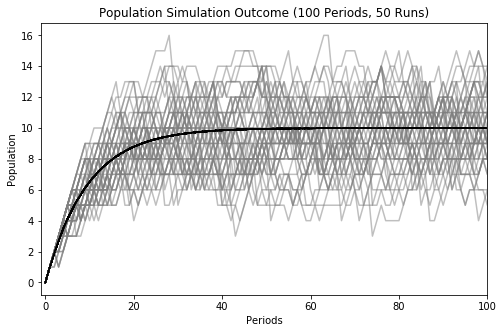

In [29]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

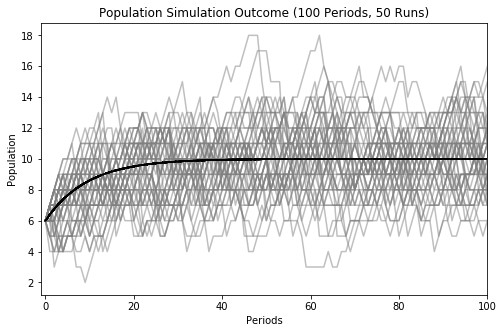

In [30]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
starting_pop = 6

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

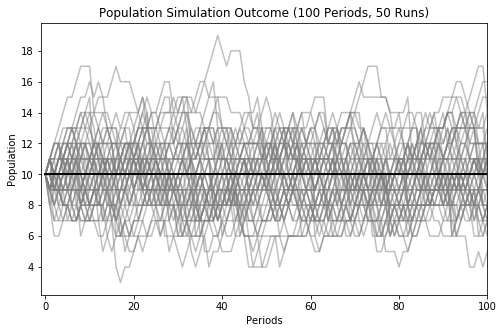

In [31]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
starting_pop = 10

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

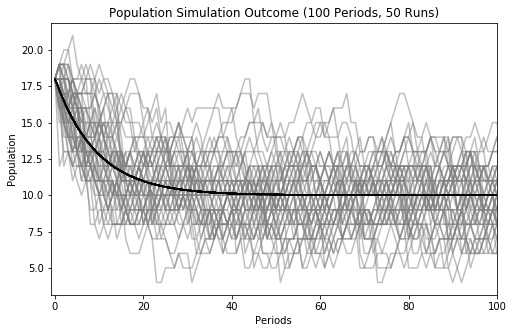

In [32]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
starting_pop = 18

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

Let's vary the `death_chance` and see how the simulation and modeling function respond.

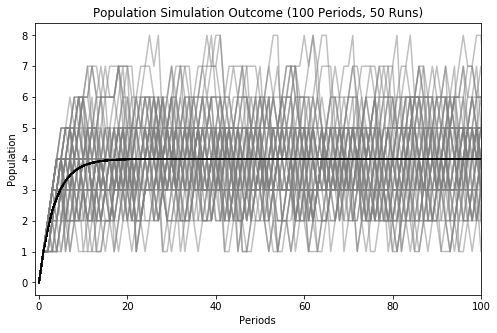

In [33]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.25
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

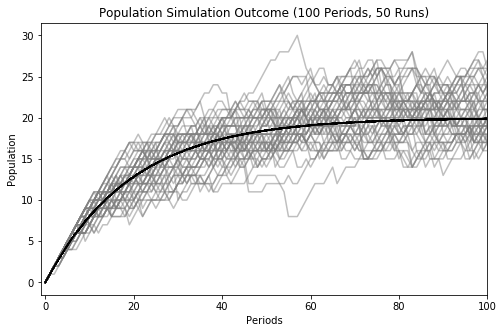

In [34]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.05
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

Let's also vary the `birth_rate` and see how the model responds.

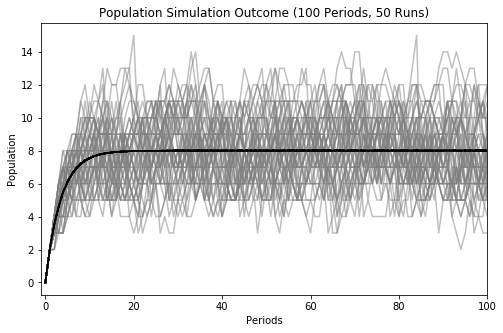

In [35]:
# Set simulation parameters
birth_rate = 2
death_chance = 0.25
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

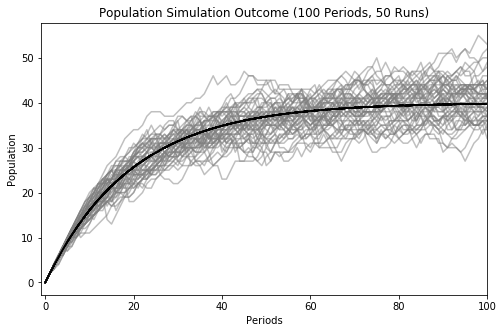

In [36]:
# Set simulation parameters
birth_rate = 2
death_chance = 0.05
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

### Conclusion

As you can see, the simplified function provides the same result as the more complex function given in part 8.